In [94]:
import yfinance as yf

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [96]:
from sklearn.preprocessing import MinMaxScaler

In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [163]:
ticker = 'GOOGL'
df = yf.download(ticker, period='max')

/tmp/ipython-input-3632850466.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='max')
[*********************100%***********************]  1 of 1 completed


In [164]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2004-08-19,2.492180,2.584575,2.383392,2.483736,893181924
2004-08-20,2.690134,2.709260,2.496155,2.508822,456686856
2004-08-23,2.717207,2.818544,2.708514,2.750738,365122512
2004-08-24,2.604694,2.771850,2.572406,2.762908,304946748
2004-08-25,2.632761,2.682435,2.580105,2.606930,183772044


In [165]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2026-02-02,343.690002,344.829987,335.630005,336.220001,32006100
2026-02-03,339.709991,349.000000,337.470001,347.339996,36506700
2026-02-04,333.040009,343.309998,328.519989,342.959991,70618400
2026-02-05,331.250000,332.690002,306.459991,312.220001,88205800
2026-02-06,322.859985,330.380005,319.920013,327.179993,56294700


In [166]:
close = df['Close'].values.reshape(-1,1)

In [167]:
print(f"The most recent closing price for the stock is {close[-1][0]}")

The most recent closing price for the stock is 322.8599853515625


In [168]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close)

In [169]:
def sequences(dataset,time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

In [170]:
X,y = sequences(scaled_data, 60)

In [171]:
X = X.reshape(X.shape[0],X.shape[1],1)

In [172]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]


In [173]:
X_train

array([[[2.40196193e-05],
        [6.04179198e-04],
        [6.83524648e-04],
        ...,
        [5.00014267e-03],
        [4.93899623e-03],
        [6.04253335e-03]],

       [[6.04179198e-04],
        [6.83524648e-04],
        [3.53771435e-04],
        ...,
        [4.93899623e-03],
        [6.04253335e-03],
        [5.96828810e-03]],

       [[6.83524648e-04],
        [3.53771435e-04],
        [4.36029285e-04],
        ...,
        [6.04253335e-03],
        [5.96828810e-03],
        [6.17720114e-03]],

       ...,

       [[3.85773378e-01],
        [3.89048682e-01],
        [3.87556460e-01],
        ...,
        [3.92526167e-01],
        [3.97940885e-01],
        [4.18037813e-01]],

       [[3.89048682e-01],
        [3.87556460e-01],
        [3.90972812e-01],
        ...,
        [3.97940885e-01],
        [4.18037813e-01],
        [4.16965916e-01]],

       [[3.87556460e-01],
        [3.90972812e-01],
        [3.90664601e-01],
        ...,
        [4.18037813e-01],
        [4.1696

In [174]:
y_test

array([0.41575436, 0.41914455, 0.42400089, ..., 0.98833546, 0.9687872 ,
       0.96354108])

In [175]:
model = Sequential([LSTM(50, return_sequences=True, input_shape=(60, 1)),
                    LSTM(50, return_sequences=False),
                    Dense(25),
                    Dense(1)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [176]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [177]:
model.fit(X_train,y_train,batch_size=32, epochs=20, validation_data=(X_test,y_test))

Epoch 1/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0016 - val_loss: 5.0126e-04
Epoch 2/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.7332e-05 - val_loss: 4.8005e-04
Epoch 3/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.9103e-05 - val_loss: 4.5937e-04
Epoch 4/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.2080e-05 - val_loss: 4.8329e-04
Epoch 5/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.3048e-05 - val_loss: 3.9254e-04
Epoch 6/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.9984e-05 - val_loss: 3.7991e-04
Epoch 7/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.5728e-05 - val_loss: 4.4194e-04
Epoch 8/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7719e-05 - val_loss: 3.3569e-04
Epoch 9/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0628e-05 - val_loss: 3.0478e-04
Epoch 10/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1358e-05 - val_loss: 2.7826e-04
Epoch 11/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss:

In [178]:
y_preds = model.predict(X_test)

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [179]:
y_preds

array([[0.4236182],
       [0.4255061],
       [0.427337 ],
       ...,
       [1.0014731],
       [1.0057663],
       [1.0035884]], dtype=float32)

In [180]:
y_preds = scaler.inverse_transform(y_preds)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

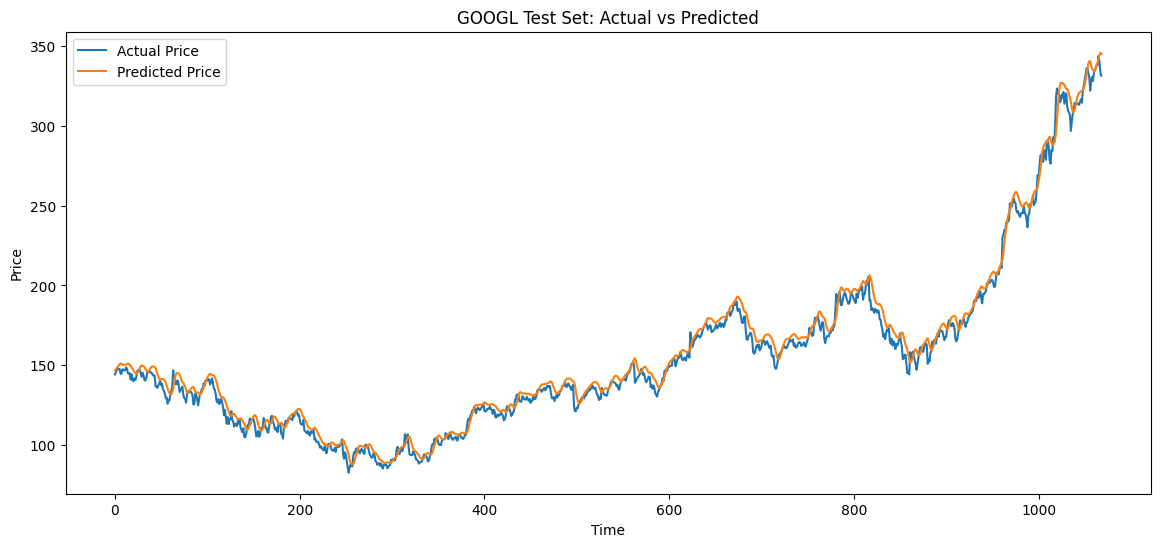

In [181]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_inv, label='Actual Price')
plt.plot(y_preds, label='Predicted Price')
plt.title(f'{ticker} Test Set: Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [182]:
time_step = 60

In [183]:
last60days = scaled_data[-time_step:]
last60days = last60days.reshape((1, time_step, 1))

In [184]:
next_day_pred_scaled = model.predict(last60days)
next_day_pred = scaler.inverse_transform(next_day_pred_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [185]:
print(f"\nPredicted next trading day's closing price for {ticker}: ${next_day_pred[0][0]:.2f}")


Predicted next trading day's closing price for GOOGL: $338.97


In [186]:
preds = []
x  = last60days.copy()

for i in  range(3):
    p  =  model.predict(x)
    preds.append(p[0, 0])
    x =  np.roll(x, -1, axis=1)
    x[0, -1, 0] = p[0, 0]

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1))
predsflatten = preds.flatten()
predsflatten

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([338.9687 , 338.39185, 339.12363], dtype=float32)